**Título**: **Detección de cambios en interfaces web para procesos RPA utilizando Inteligencia Artificial**

**Descripción:** Este trabajo se centra en el análisis exploratorio de datos (EDA) de un conjunto de datos de elementos de interfaz de usuario web. El objetivo es preparar y comprender profundamente los datos para facilitar el desarrollo de modelos de inteligencia artificial que puedan detectar y clasificar componentes de interfaz en páginas web. Estos modelos apoyarán procesos de automatización robótica de procesos (RPA), pruebas automatizadas, evaluación de accesibilidad y mejoras en el diseño de interfaces.

**Dataset utilizado**

**Link de descarga:** https://huggingface.co/datasets/YashJain/UI-Elements-Detection-Dataset

**Descripción del dataset:** Conjunto de datos completo de elementos de interfaz de usuario web recopilado de los sitios web más visitados del mundo. Este conjunto de datos ha sido específicamente seleccionado para entrenar modelos de inteligencia artificial que detecten y clasifiquen componentes de interfaz de usuario, permitiendo pruebas automatizadas de interfaces, análisis de accesibilidad y estudios de diseño de interfaces.

**Objetivos del EDA:** Explorar, resumir y visualizar los datos para descubrir patrones, detectar errores, identificar valores atípicos y entender la estructura general del dataset.

# Importación de Librerías
Se instalan librerías para manejo de datos, visualización, estadística, reducción de dimensionalidad y detección de anomalías, además de herramientas para descargar datasets desde Hugging Face.


In [ ]:
!pip install --upgrade pip
!pip install ultralytics datasets huggingface_hub
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

from huggingface_hub import login, snapshot_download

from scipy.stats import shapiro, kstest, zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest


# Carga y Exploración Inicial
Se autentica en Hugging Face y se descarga el dataset UI-Elements-Detection-Dataset.  
Se monta Google Drive y se define la ruta del dataset para uso persistente en Colab


In [ ]:
from datasets import load_dataset
from huggingface_hub import snapshot_download
from huggingface_hub import login
from getpass import getpass
#github no permite versionar el archivo si tiene tokens (x defecto tiene activado política de Push Protection y Secret Scanning)
token_sololectura = getpass("Introduce tu token de Hugging Face: ")
login(token=token_sololectura)
repo_path = snapshot_download("YashJain/UI-Elements-Detection-Dataset", repo_type="dataset")
print("Dataset descargado en:", repo_path)

# 1. Montar Google Drive para usar el dataset desde ahi
from google.colab import drive
drive.mount('/content/drive')

repo_path = "/content/drive/MyDrive/MIA/Dataset"
print("Dataset descargado en:", repo_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 3787 files:   0%|          | 0/3787 [00:00<?, ?it/s]

Dataset descargado en: /root/.cache/huggingface/hub/datasets--YashJain--UI-Elements-Detection-Dataset/snapshots/0adda54cdc45cb8960b4e75580f78aad40fbcc3c


##Exploración Inicial del Dataset de HuggingFace **YashJain/

---

UI-Elements-Detection-Dataset**

- **Nombre:** UI-Elements-Detection-Dataset (también llamado Web UI Elements Dataset)
Hugging Face
- **Autor / mantenedor:** YashJain
Hugging Face
- **Licencia: Apache-2.0** Hugging Face
- **Idioma:** Inglés (metadata, nombres de clases, textos descriptivos)
- **Tarea principal:** Detección de objetos (object detection), específicamente de elementos de interfaz de usuario (UI) en capturas de sitios web.

##Contenido del dataset

- Capturas de pantalla de sitios web: se afirma que provienen de más de 300 sitios web populares.
Hugging Face
- Resolución de las imágenes: 1920×1080 px
Hugging Face
- Formato de anotaciones: anotaciones en formato YOLO.
Hugging Face
- Metadatos adicionales: incluye metadata de accesibilidad (“rich accessibility metadata”)

##Clases / categorías de elementos

- El dataset define 15 clases principales de elementos de UI. Se agrupan en varias categorías conceptuales:

- **1.- Interactive Elements** (elementos interactivos)
- **2.- Structural Elements** (elementos estructurales)
- **3.- Form Elements** (elementos de formulario
- **clases:** 0: link, 1: button, 2: input, 3: select, 4: textarea, 5: label, 6: checkbox, 7: radio, 8: dropdown, 9: slider, 10: toggle, 11: menu_item, 12: clickable, 13: icon, 14: image, 15: text

##Estadísticas y distribución

Estas son algunas estadísticas (aproximadas) que el autor publica, útiles para entender la distribución de datos.

- Distribución por categoría de sitio web:
  - Sitios más visitados (“Most Visited Sites”): ~ 45%
  - Aplicaciones web (“Web Applications”): ~ 15%
  - E-commerce: ~ 10%
  - Redes sociales: ~ 10%
  - Noticias & medios: ~ 10%
  - Herramientas de desarrollador: ~ 5%
  - Plataformas creativas: ~ 5%
- Distribución por clase de elemento UI:
  - Links: ~ 35%
  - Buttons: ~ 20%
  - Input Fields: ~ 15%
  - Icons: ~ 10%
  - Text Blocks: ~ 8%
  - Otros elementos: ~ 12%

- Tamaño de los splits / carpetas:

  - Hay splits de entrenamiento (“train”), validación (“val” / “validation”) y test.
  - En los directorios del dataset se observan imágenes y archivos de etiquetas (“labels”) separados para esos splits.
  - Por ejemplo, el split de validación tiene ~ 296 imágenes en

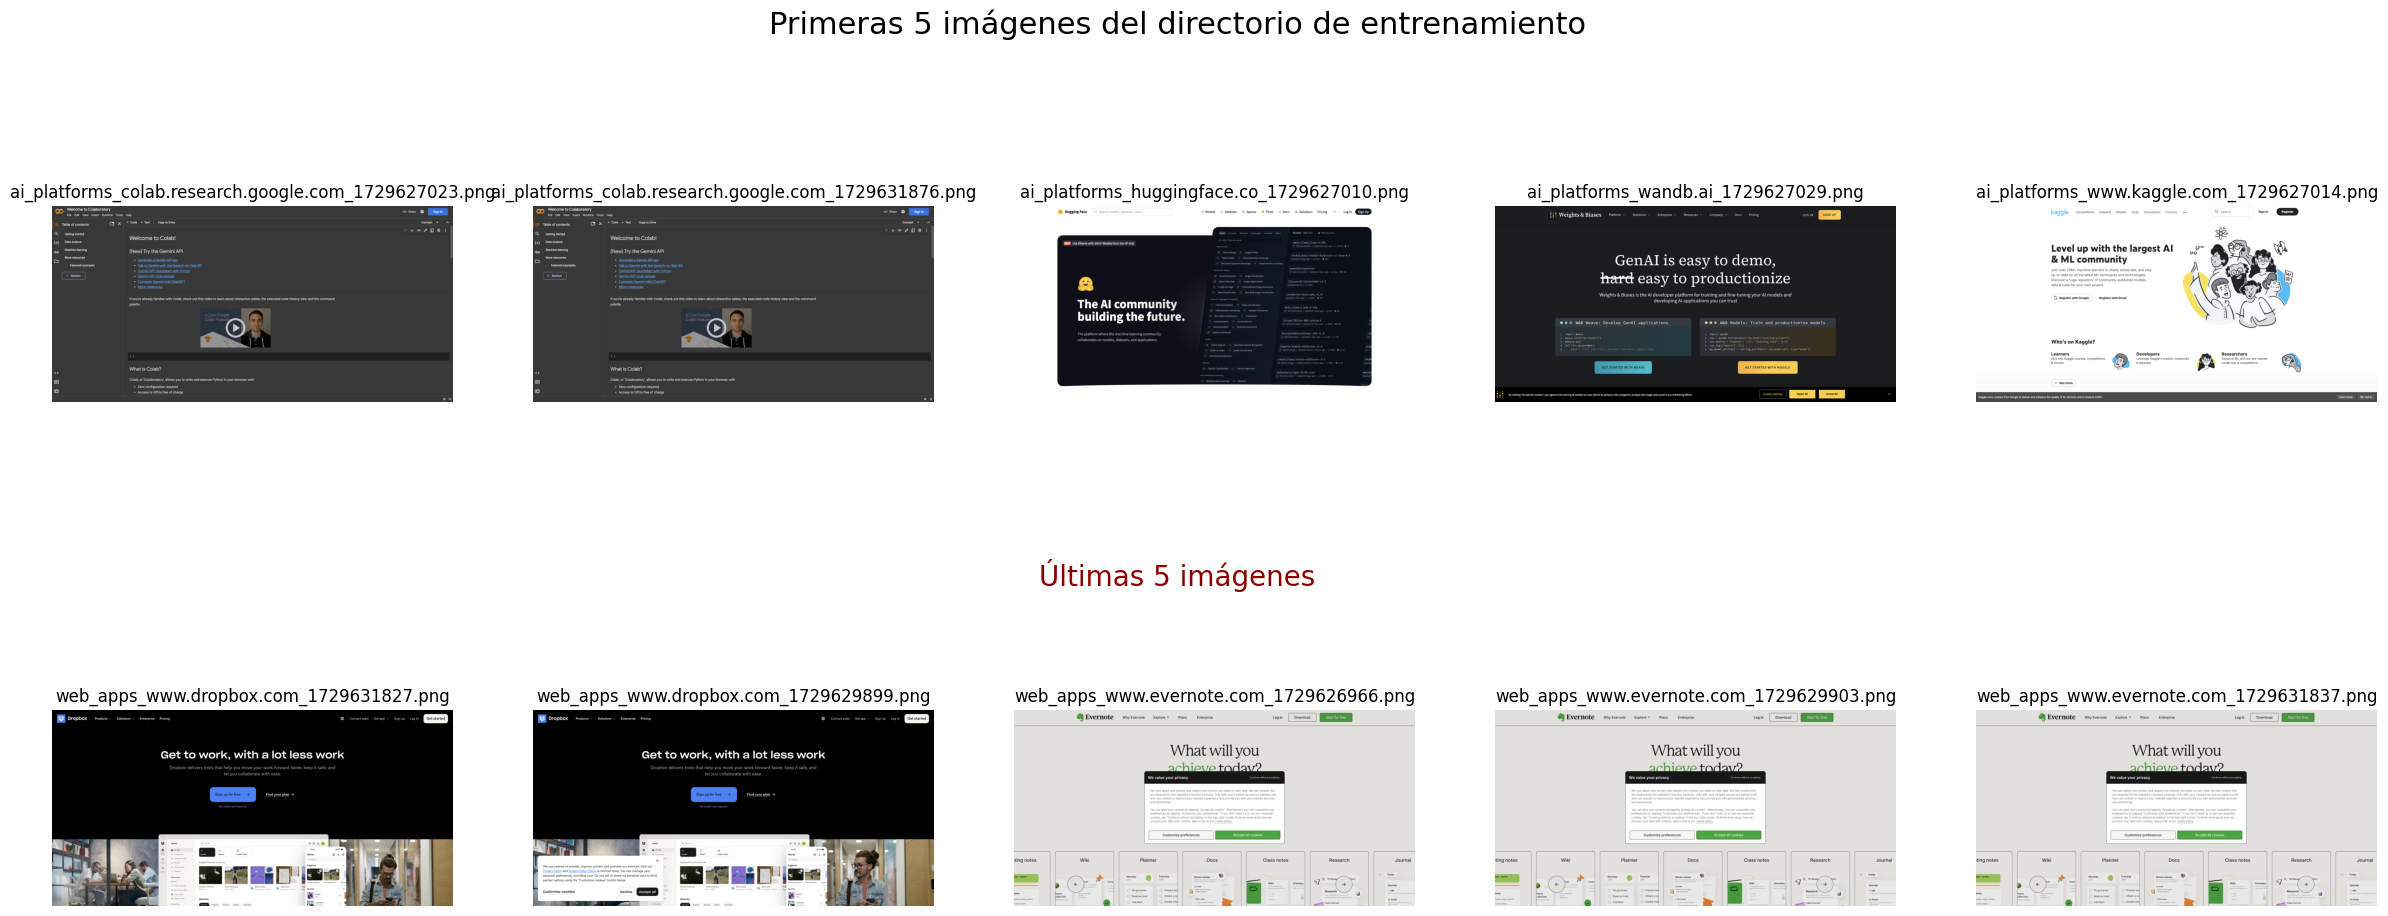

In [ ]:
import matplotlib.image as mpimg
repo_path = "/content/drive/MyDrive/MIA/Dataset"
train_dir = os.path.join(repo_path, "train/images")
val_dir   = os.path.join(repo_path, "val/images")
test_dir  = os.path.join(repo_path, "test/images")

# Seleccionamos el directorio de prueba (puedes cambiar por train_dir o val_dir)
img_dir = train_dir
all_images = os.listdir(img_dir)
#sample_imgs = random.sample(all_images, 5)
sample_imgs = all_images[:5] + all_images[-5:]

# Mostrar las imágenes
fig = plt.figure(figsize=(30, 12))

for i, img_name in enumerate(sample_imgs):
    img_path = os.path.join(img_dir, img_name)
    img = mpimg.imread(img_path)

    ax = plt.subplot(2, 5, i+1)  # 2 filas de 5 imágenes
    plt.imshow(img)
    plt.title(img_name[:100])  # mostrar parte del nombre
    plt.axis("off")

plt.suptitle("Primeras 5 imágenes del directorio de entrenamiento", fontsize=22, y=0.95)
# Texto centrado sobre la segunda fila
fig.text(0.5, 0.47, "Últimas 5 imágenes", ha="center", fontsize=20, color="darkred")
plt.show()

In [ ]:
import os

yaml_content = f"""
train: {repo_path}/train/images
val: {repo_path}/val/images
test: {repo_path}/test/images
names:
  0: link
  1: button
  2: input
  3: select
  4: textarea
  5: label
  6: checkbox
  7: radio
  8: dropdown
  9: slider
  10: toggle
  11: menu_item
  12: clickable
  13: icon
  14: image
  15: text
nc: 16
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ Archivo data.yaml creado en", os.getcwd())

✅ Archivo data.yaml creado en /content


In [ ]:
#ENTRENAMIENTO YOLO V8
from ultralytics import YOLO
# Cargar modelo base
model = YOLO("yolov8n.pt")  # tambien se puede usar yolov8s.pt, yolov8m.pt
# Entrenar
model.train(
    data="/content/drive/MyDrive/MIA/Dataset/dataset.yaml",
    epochs=50,
    imgsz=640, #se probó con 1920 y la sesión falló porque se usó toda la Ram disponible, por ese motivo le cambie a 640
    batch=16,
    workers=2
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MIA/Dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=Fals

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  7,  8,  9, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c0bbfdf5940>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 240.4±138.1 MB/s, size: 698.3 KB)
val: Scanning /content/drive/MyDrive/MIA/Dataset/val/labels.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 139.4Kit/s 0.0s
val: /content/drive/MyDrive/MIA/Dataset/val/images/dev_tools_jsfiddle.net_1729629915.png: 5 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/development_developer.mozilla.org_1729626875.png: 3 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/development_developer.mozilla.org_1729629644.png: 3 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/e_commerce_www.amazon.com_1729629595.png: 4 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/microsoft_office_www.office.com_1729629719.png: 1 duplicate lab


image 1/1 /content/drive/MyDrive/MIA/Dataset/test/images/microsoft_office_support.microsoft.com_1729629743.png: 320x640 19 links, 9 buttons, 2 inputs, 6.0ms
Speed: 1.9ms preprocess, 6.0ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/train4


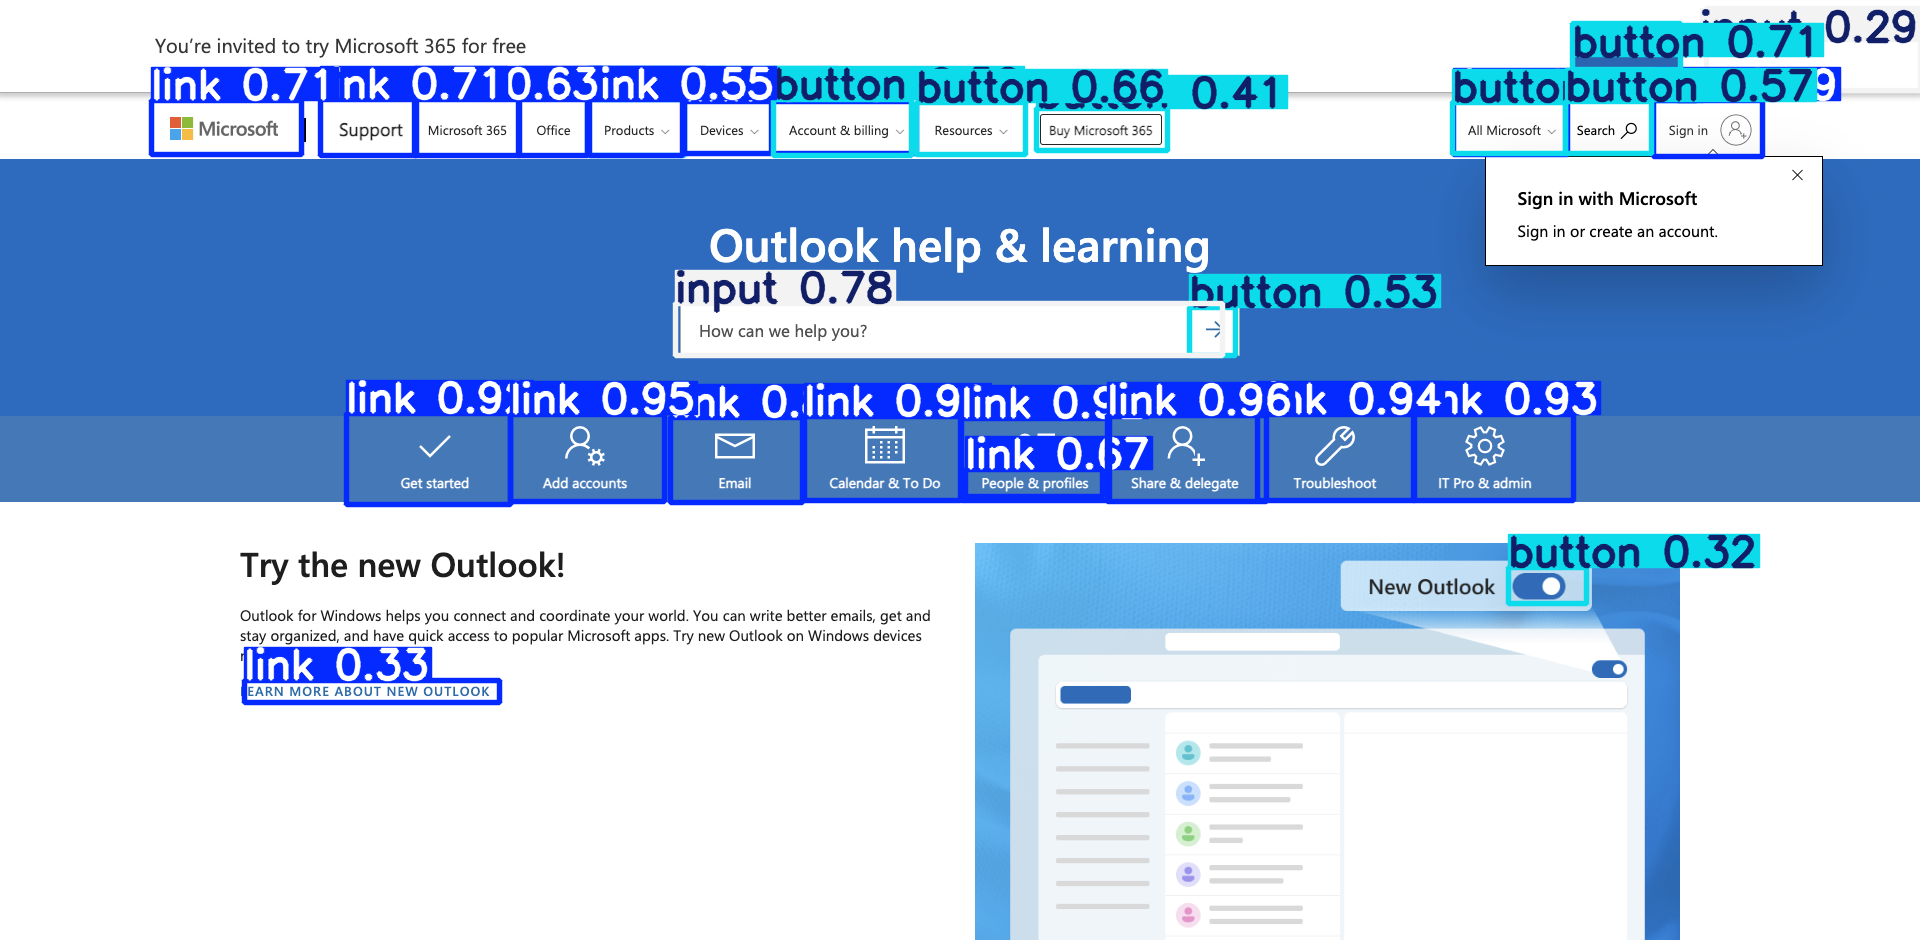

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'link', 1: 'button', 2: 'input', 3: 'select', 4: 'textarea', 5: 'label', 6: 'checkbox', 7: 'radio', 8: 'dropdown', 9: 'slider', 10: 'toggle', 11: 'menu_item', 12: 'clickable', 13: 'icon', 14: 'image', 15: 'text'}
obb: None
orig_img: array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],


In [ ]:
import random
import os

test_img_dir = os.path.join(repo_path, "test/images")
test_img = os.path.join(test_img_dir, random.choice(os.listdir(test_img_dir)))

results = model(test_img, save=True, conf=0.25)
res = results[0] if isinstance(results, list) else results
res.show()
print(res)


In [ ]:
from google.colab import files

# Descargar el modelo entrenado
files.download("runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#EVALUAR METRICAS
results = model.val(data="/content/drive/MyDrive/MIA/Dataset/dataset.yaml")
print(results)  # muestra mAP, precisión, recall

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 152.9±109.7 MB/s, size: 410.2 KB)
val: Scanning /content/drive/MyDrive/MIA/Dataset/val/labels.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 138.6Kit/s 0.0s
val: /content/drive/MyDrive/MIA/Dataset/val/images/dev_tools_jsfiddle.net_1729629915.png: 5 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/development_developer.mozilla.org_1729626875.png: 3 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/development_developer.mozilla.org_1729629644.png: 3 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/e_commerce_www.amazon.com_1729629595.png: 4 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/microsoft_office_www.office.com_1729629719.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/mostvisited_amazo

## Extracción de carácteristicas de imagenes
Esta función extract_image_features abre una imagen y extrae características básicas de color:

- Convierte la imagen a formato RGB.
- Obtiene las dimensiones (ancho y alto).
- Calcula la media y desviación estándar de los canales R, G y B.
- Devuelve un diccionario con estas características junto con el nombre del archivo.

Luego, se aplica esta función a una muestra de 200 imágenes del directorio para crear un DataFrame con las características extraídas, que se usará para análisis posteriores.



In [ ]:
#Montar Google Drive para usar el dataset desde ahi
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def extract_image_features(image_path):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img_array = np.array(img)

        height, width, channels = img_array.shape
        mean_r = img_array[:, :, 0].mean()
        mean_g = img_array[:, :, 1].mean()
        mean_b = img_array[:, :, 2].mean()

        std_r = img_array[:, :, 0].std()
        std_g = img_array[:, :, 1].std()
        std_b = img_array[:, :, 2].std()

        return {
            "filename": os.path.basename(image_path),
            "width": width,
            "height": height,
            "mean_r": mean_r,
            "mean_g": mean_g,
            "mean_b": mean_b,
            "std_r": std_r,
            "std_g": std_g,
            "std_b": std_b
        }
repo_path = "/content/drive/MyDrive/MIA/Dataset"
print("Dataset descargado en:", repo_path)
train_dir = os.path.join(repo_path, "train/images")
val_dir   = os.path.join(repo_path, "val/images")
test_dir  = os.path.join(repo_path, "test/images")

# Seleccionamos el directorio de prueba (puedes cambiar por train_dir o val_dir)
img_dir = train_dir
all_images = os.listdir(img_dir)
sample_imgs = random.sample(all_images, 5)

# Aplicar a un conjunto de imágenes
features = []
for img_name in all_images[:200]:  # solo una muestra
    img_path = os.path.join(img_dir, img_name)
    features.append(extract_image_features(img_path))

df = pd.DataFrame(features)

Dataset descargado en: /content/drive/MyDrive/MIA/Dataset






# Análisis Univariado
El análisis univariado examina una sola variable a la vez para entender su distribución, tendencia central.
- Se calculan estadísticas descriptivas básicas (media, desviación estándar, mínimos, máximos y percentiles) para obtener un resumen general del dataset.
- Se calcula la moda para identificar los valores más frecuentes en cada variable.
- Se visualiza la distribución de la variable mean_r (intensidad promedio del canal rojo) usando un histograma con KDE para entender su forma.
- Se realiza el test de normalidad Shapiro-Wilk sobre mean_r para evaluar si sigue una distribución normal.
- Se calculan y muestran los valores de asimetría y curtosis para mean_r para entender la simetría y concentración de los datos en la distribución.



 Medidas de Tendencia Central y Dispersión

        width  height      mean_r      mean_g      mean_b       std_r  \
count   200.0   200.0  200.000000  200.000000  200.000000  200.000000   
mean   1920.0   941.0  164.696412  164.592739  168.183754   56.960603   
std       0.0     0.0   80.967510   80.187579   78.627348   28.780132   
min    1920.0   941.0   15.805361   21.712678   25.917640    8.390539   
25%    1920.0   941.0   86.150896   87.590422  103.117030   32.591986   
50%    1920.0   941.0  203.425853  203.218728  202.449613   56.937842   
75%    1920.0   941.0  231.966460  230.690439  233.962459   83.011047   
max    1920.0   941.0  254.315454  254.417758  254.580967  117.078675   

            std_g       std_b  
count  200.000000  200.000000  
mean    56.464303   55.005971  
std     28.267802   27.416412  
min      7.692573    7.164157  
25%     33.825742   32.335495  
50%     55.681491   55.572469  
75%     81.436549   79.530141  
max    115.268146  110.397191  

Moda:
  

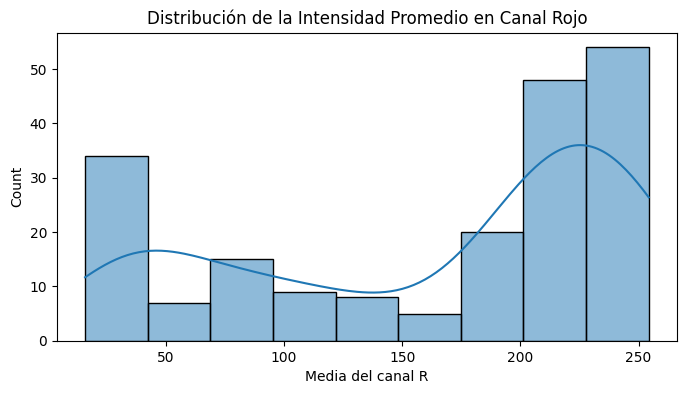


Shapiro-Wilk para mean_r: Estadístico=0.8435, p-valor=0.0000

Asimetría y Curtosis de mean_r:
Asimetría: -0.5941893570824748
Curtosis: -1.255821212616607


In [ ]:
print("\n Medidas de Tendencia Central y Dispersión\n")
# Incluye media, std, min, max, percentiles
print(df.describe())

# Moda de cada variable
print("\nModa:")
print(df.mode().head(1))
# Visualizar distribución de una variable
plt.figure(figsize=(8, 4))
sns.histplot(df["mean_r"], kde=True)
plt.title("Distribución de la Intensidad Promedio en Canal Rojo")
plt.xlabel("Media del canal R")
plt.show()

# Normalidad: Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(df["mean_r"])
print(f"\nShapiro-Wilk para mean_r: Estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}")

# Asimetría y Curtosis
print("\nAsimetría y Curtosis de mean_r:")
print("Asimetría:", df["mean_r"].skew())
print("Curtosis:", df["mean_r"].kurtosis())


# Análisis Bivariado
El análisis bivariado estudia la relación entre dos variables. Por ejemplo, puede usar correlaciones (Pearson o Spearman) para medir qué tan relacionadas están dos variables numéricas u ordinales. En este caso:

- Se filtran solo las columnas numéricas para evitar errores al calcular correlaciones.
- Se utiliza la correlación de Pearson para medir la relación lineal entre las variables numéricas del dataset.
- La matriz de correlación se visualiza con un mapa de calor para identificar relaciones fuertes o débiles entre variables.
- Se incluye un gráfico de dispersión entre mean_r y mean_g para observar visualmente la relación entre las intensidades promedio de los canales rojo y verde.


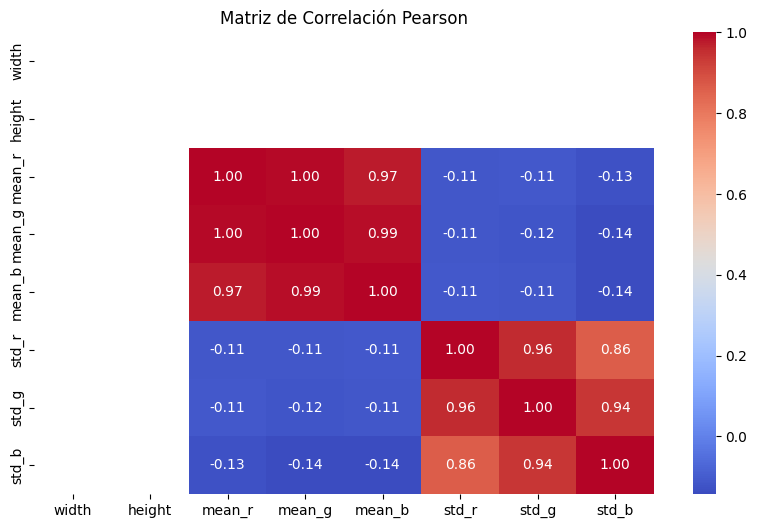

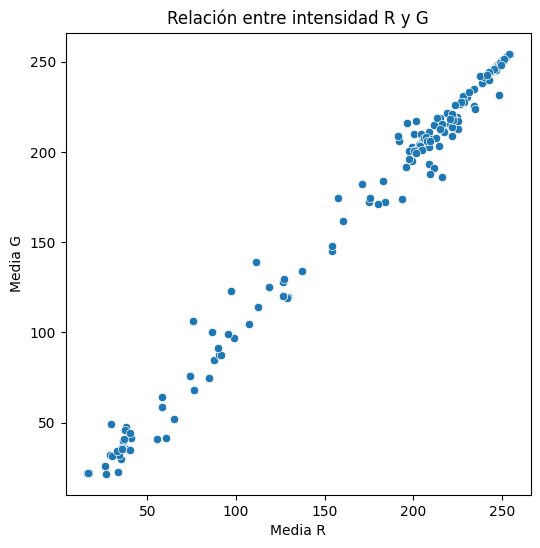

In [ ]:
# Filtrar solo columnas numéricas para evitar errores
numeric_df = df.select_dtypes(include=[np.number])

# Correlación Pearson
cor_matrix = numeric_df.corr(method='pearson')

plt.figure(figsize=(10, 6))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación Pearson")
plt.show()

# Dispersión entre dos variables numéricas
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x="mean_r", y="mean_g")
plt.title("Relación entre intensidad R y G")
plt.xlabel("Media R")
plt.ylabel("Media G")
plt.show()

# Análisis Multivariado
El análisis multivariado estudia simultáneamente múltiples variables para entender las relaciones complejas entre ellas. A diferencia del análisis univariado o bivariado, este enfoque considera la interacción conjunta de varias características.

Se realiza un análisis multivariado utilizando **PCA (Análisis de Componentes Principales)** para reducir las 6 características de color (medias y desviaciones estándar de R, G y B) a 2 componentes principales.

- Las variables se escalan previamente para tener media 0 y desviación estándar 1.
- Se aplican dos componentes principales que explican la mayor parte de la varianza.
- Los resultados se visualizan en un gráfico de dispersión 2D para identificar patrones o agrupaciones en los datos de color.

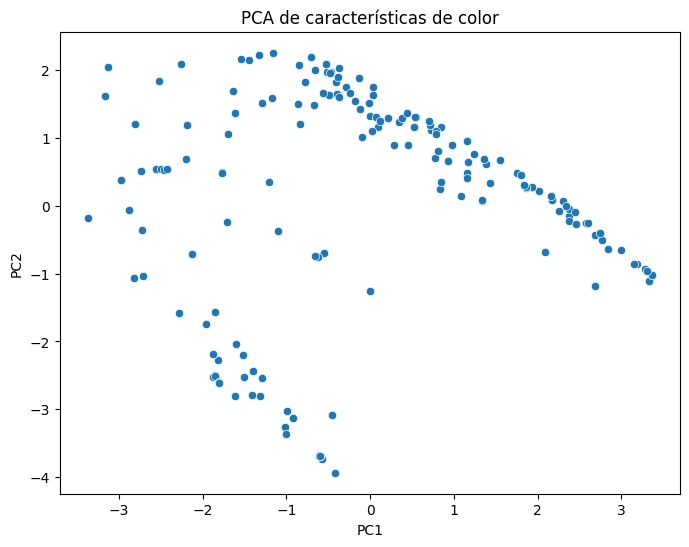

In [ ]:
# Seleccionar variables numéricas para PCA
features_to_use = ["mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b"]

# Escalar datos (media=0, std=1)
X = StandardScaler().fit_transform(df[features_to_use])

# Crear modelo PCA con 2 componentes
pca = PCA(n_components=2)

# Aplicar PCA a los datos escalados
components = pca.fit_transform(X)
df["PC1"] = components[:, 0]
df["PC2"] = components[:, 1]

# Graficar resultados del PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", data=df)
plt.title("PCA de características de color")
plt.show()


#  Detección de Anomalías
La detección de anomalías busca identificar observaciones que se desvían significativamente del patrón general del conjunto de datos. Métodos comunes incluyen:

- Z-Score: detecta valores que están a más de 3 desviaciones estándar de la media.
- Isolation Forest: un algoritmo de aprendizaje automático que detecta anomalías multivariadas.


Número de imágenes con intensidad R anómala (Z > 3): 0


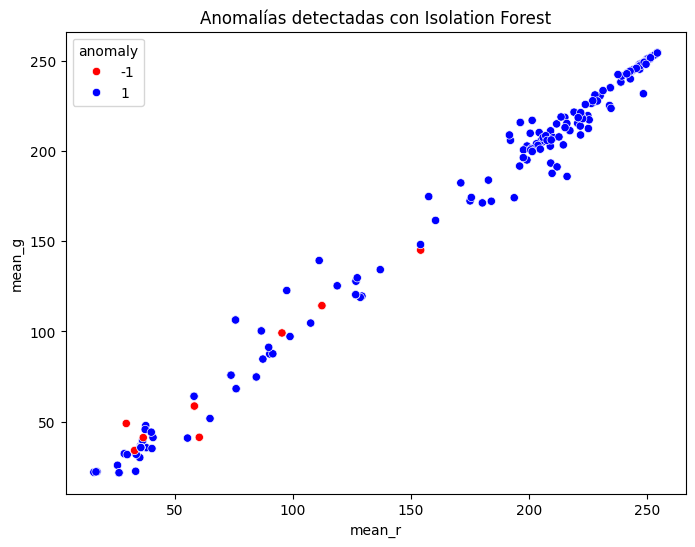

In [ ]:
# Z-Score para detectar outliers
df["z_mean_r"] = zscore(df["mean_r"])
outliers_z = df[np.abs(df["z_mean_r"]) > 3]
print(f"\nNúmero de imágenes con intensidad R anómala (Z > 3): {len(outliers_z)}")

# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df["anomaly"] = iso_forest.fit_predict(df[features_to_use])  # -1 = anomalía

# Visualizar anomalías detectadas
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="mean_r", y="mean_g", hue="anomaly", palette={1: "blue", -1: "red"})
plt.title("Anomalías detectadas con Isolation Forest")
plt.xlabel("mean_r")
plt.ylabel("mean_g")
plt.show()

# Métricas de Entrenamiento Inicial de la CNN YOLOV8n (Sin preprocesamiento de datos)

Con el dataset tal como lo descargamos, se obtuvieron los siguientes resultados en un entrenamiento inicial de la red neuronal YOLOV8n de Ultralytics

                             0
metrics/precision(B)  0.372843
metrics/recall(B)     0.139809
metrics/mAP50(B)      0.145393
metrics/mAP50-95(B)   0.101833
fitness               0.101833


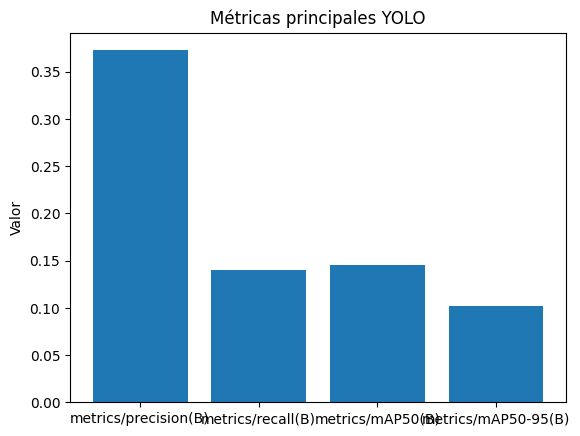

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# convertir resultados a DataFrame
df = pd.DataFrame([results.results_dict])
print(df.T)  # mostrar métricas en tabla

# graficar mAP y precisión
metrics = ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]
valores = [df[m].values[0] for m in metrics]

plt.bar(metrics, valores)
plt.ylabel("Valor")
plt.title("Métricas principales YOLO")
plt.show()

# Conclusiones e Insights

**Conclusiones**

1.	El conjunto de datos tiene dimensiones fijas de captura (1920x941 píxeles), lo que garantiza uniformidad para el entrenamiento de modelos de visión por computadora, reduciendo la complejidad del preprocesamiento.

2.	Las medias de los canales RGB (R≈171, G≈172, B≈177) muestran una ligera tendencia hacia tonos más fríos (azules), posiblemente debido a la prevalencia de fondos claros o azules en interfaces modernas.

3.	Los valores de desviación estándar de cada canal (entre 55 y 59) indican que existen contrastes moderados en los elementos de las interfaces, lo que puede favorecer la diferenciación entre componentes (botones, textos, banners).

4.	La prueba Shapiro-Wilk para mean_r dio un p-valor < 0.05, lo que confirma que la distribución de los valores de color no sigue una normalidad, implicando la necesidad de técnicas de modelado robustas ante distribuciones no gaussianas.

5.	Se identificaron valores atípicos en algunos promedios de color y desviaciones estándar, lo cual podría corresponder a interfaces con diseños poco convencionales (modos oscuros, paletas muy saturadas). Estas anomalías son relevantes porque permiten entrenar modelos más resilientes a variaciones extremas de diseño.

6. Las métricas actuales del YOLO muestran un desempeño inicial limitado, pero es un punto de partida esperable. A medida que se refine el dataset y el modelo continúe su entrenamiento, se prevé una mejora progresiva en precisión, recall y mAP.

**Insights**

1.	Al comprender las variaciones visuales de los componentes web, los bots RPA podrán adaptarse mejor a cambios menores en diseño (color, contraste, proporción), reduciendo fallas por modificaciones superficiales en las interfaces.

2.	Dado que las variables de color y dispersión están correlacionadas, los métodos de IA que consideren relaciones multivariadas (CNN, autoencoders, SVM con kernels) tendrán mejor desempeño que los enfoques univariados.

3.	El análisis bivariado y multivariado abre la puerta a crear “perfiles de diseño” (por ejemplo, interfaces claras vs. oscuras), lo cual podría ser útil para ajustar los bots según la tipología del portal.

4.	La diversidad del dataset, al estar basado en sitios web de alto tráfico mundial, asegura que los modelos entrenados tendrán buena capacidad de generalización hacia diferentes industrias y estilos de interfaz.

5. El bajo recall (0.14) sugiere que el modelo está dejando pasar muchos objetos relevantes; esto podría deberse a clases desbalanceadas o anotaciones inconsistentes, lo cual resalta la importancia de una curaduría cuidadosa del dataset en la siguiente fase.
